In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv')

In [3]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1385,flat,dlf new town heights,sector 90,1.54,6514.0,2364.0,Super Built up area 2364(219.62 sq.m.)Built Up...,4.0,4.0,3+,...,2364.0,2200.0,1850.0,0,1,0,1,0,2,111
757,flat,bptp astaire gardens,sector 70a,1.80,9350.0,1925.0,Built Up area: 1925 (178.84 sq.m.),3.0,3.0,3,...,NaN,1925.0,NaN,1,0,0,0,0,0,135
3670,flat,raheja vedaanta,sector 108,1.00,4854.0,2060.0,Built Up area: 2060 (191.38 sq.m.)Carpet area:...,2.0,2.0,2,...,NaN,2060.0,1890.0,0,0,0,0,0,0,0
513,house,independent,sector 25,16.00,59259.0,2700.0,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16.0,16.0,3+,...,NaN,325.0,300.0,1,1,1,1,0,2,72
3083,flat,pyramid urban homes 2,sector 86,0.42,8483.0,495.0,Carpet area: 501 (46.54 sq.m.),2.0,2.0,1,...,NaN,NaN,501.0,1,1,0,1,1,0,84


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3852 entries, 0 to 3851
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3852 non-null   object 
 1   society              3851 non-null   object 
 2   sector               3852 non-null   object 
 3   price                3785 non-null   float64
 4   price_per_sqft       3825 non-null   float64
 5   area                 3785 non-null   float64
 6   areaWithType         3803 non-null   object 
 7   bedRoom              3803 non-null   float64
 8   bathroom             3803 non-null   float64
 9   balcony              3803 non-null   object 
 10  floorNum             3784 non-null   float64
 11  facing               2698 non-null   object 
 12  agePossession        3852 non-null   object 
 13  super_built_up_area  1915 non-null   float64
 14  built_up_area        1733 non-null   float64
 15  carpet_area          1944 non-null   f

In [5]:
df.shape

(3852, 23)

In [6]:
df.duplicated().sum()

np.int64(134)

In [7]:
df.drop_duplicates(inplace = True)

In [8]:
df.shape

(3718, 23)

In [9]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,zara aavaas,sector 104,0.20,6644.0,301.0,Carpet area: 301 (27.96 sq.m.),1.0,2.0,2,...,NaN,NaN,301.0,0,0,0,0,0,0,67
1,flat,landmark the residency,sector 103,0.90,6666.0,1350.0,Super Built up area 1350(125.42 sq.m.),2.0,2.0,2,...,1350.0,NaN,NaN,0,0,0,0,0,0,44
2,flat,ramprastha city,dwarka expressway,1.30,9027.0,1440.0,Super Built up area 1440(133.78 sq.m.),3.0,3.0,2,...,1440.0,NaN,NaN,0,0,0,0,0,0,0
3,flat,ireo skyon,sector 60,3.80,13571.0,2800.0,Super Built up area 2800(260.13 sq.m.)Built Up...,4.0,5.0,3,...,2800.0,2791.0,2768.0,0,1,0,0,0,2,145
4,flat,breez global heights,sector 36,0.24,5825.0,412.0,Carpet area: 412 (38.28 sq.m.),1.0,1.0,1,...,NaN,NaN,412.0,0,0,0,0,0,0,57


<Axes: xlabel='property_type'>

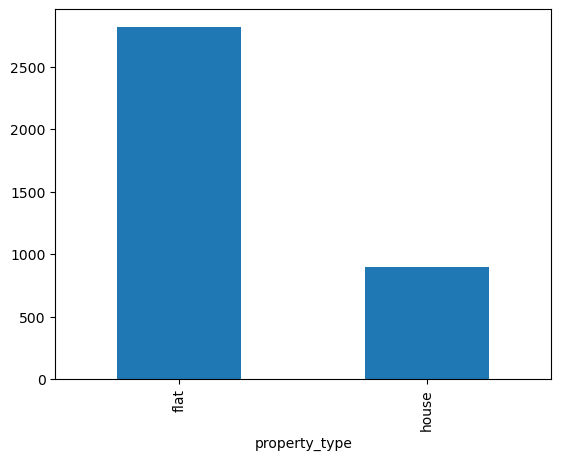

In [10]:
# property type
df['property_type'].value_counts().plot(kind='bar',)

## Observations :
### Flats are in majority(75 percent) and there are less number of houses(~25 percent)
### No missing values

In [11]:
# society
df['society'].value_counts().shape

(677,)

In [12]:
df['society'].value_counts()

society
independent                             493
tulip violet                             75
ss the leaf                              73
dlf new town heights                     42
shapoorji pallonji joyville gurugram     42
                                       ... 
the rama apartment cghs                   1
shapoorji pallonji joyville               1
takshila heights sector 37 c              1
dlf south city 1                          1
swarn jayanti cghs                        1
Name: count, Length: 677, dtype: int64

In [13]:
df[df['society'] != 'independent']['society'].value_counts(normalize=True).cumsum().head(75)
# by this sum we get to know that the 50% of flats are from 75% societies and the remaining 50% are from only 25%

society
tulip violet                            0.023263
ss the leaf                             0.045906
dlf new town heights                    0.058933
shapoorji pallonji joyville gurugram    0.071960
signature global park                   0.082816
                                          ...   
dlf the primus                          0.491625
indiabulls enigma                       0.495658
the close north                         0.499690
umang winter hills                      0.503722
ireo the corridors                      0.507444
Name: proportion, Length: 75, dtype: float64

In [14]:
# to standardize it 
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(92),
 'Low (2-9)': np.int64(277),
 'Very Low (1)': np.int64(305)}

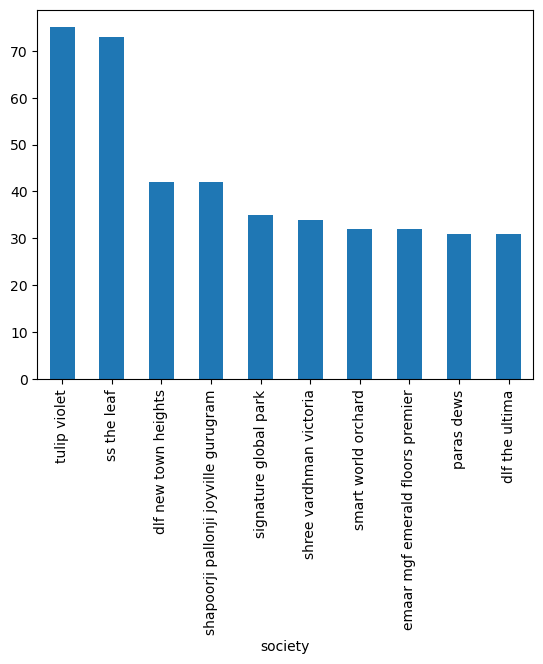

In [15]:
# top 10 socities
df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar').figsize=(1,1)

In [16]:
df['society'].isnull().sum()

np.int64(1)

## Observations
##### Around 13% properties comes under independent tag.
##### There are 675 societies.
##### The top 75 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 600 societies
##### High (50-100): 2 societies have between 50 to 100 listings.
##### Average (10-49): 92 societies fall in this range with 10 to 49 listings each.
##### Low (2-9): 273 societies have between 2 to 9 listings.
##### Very Low (1): A significant number, 308 societies, have only 1 listing.
##### 1 missing value

In [17]:
#sector
df['sector'].value_counts().shape

(113,)

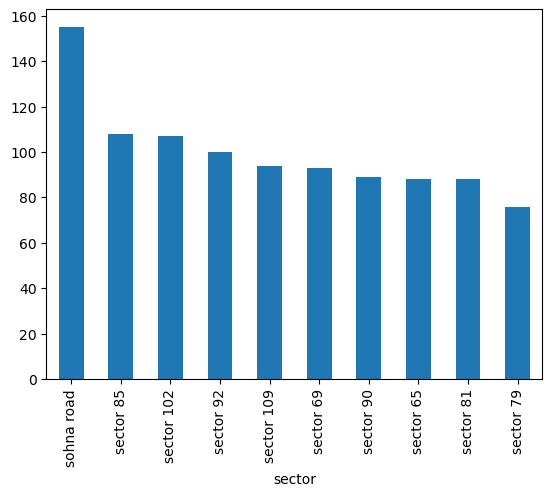

In [18]:
# top 10 sectors
df['sector'].value_counts().head(10).plot(kind='bar').figsize=(1,1)

In [19]:
# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': np.int64(3),
 'High (50-100)': np.int64(26),
 'Average (10-49)': np.int64(62),
 'Low (2-9)': np.int64(21),
 'Very Low (1)': np.int64(1)}

## Observations
##### There are a total of 113 unique sectors in the dataset.
##### Frequency distribution of sectors:
##### Very High (>100): 3 sectors have more than 100 listings.
##### High (50-100): 25 sectors have between 50 to 100 listings.
##### Average (10-49): A majority, 60 sectors, fall in this range with 10 to 49 listings each.
##### Low (2-9): 16 sectors have between 2 to 9 listings.
##### Very Low (1): Interestingly, there are no sectors with only 1 listing.

In [20]:
# Price
df['price'].isnull().sum()

np.int64(58)

In [21]:
df['price'].describe()

count    3660.000000
mean        2.533664
std         2.980623
min         0.070000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

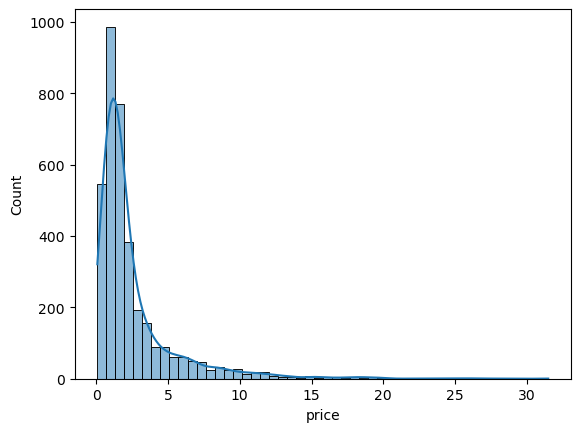

In [22]:
sns.histplot(df['price'], kde=True, bins=50)

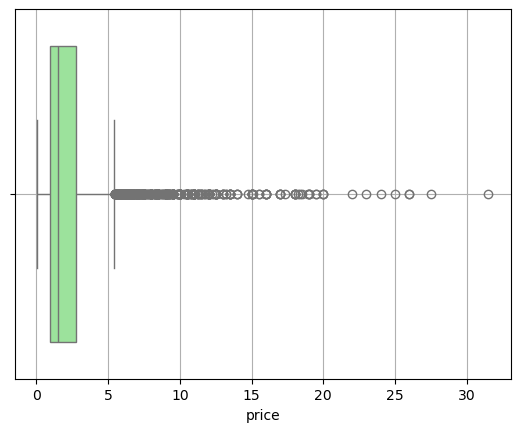

In [23]:
sns.boxplot(x=df['price'], color='lightgreen')
plt.grid()

- Descriptive Statistics:

    - Count: There are 3,660 non-missing price entries.
    - Mean Price: The average price is approximately 2.53 crores.
    - Median Price: The median (or 50th percentile) price is 1.52 crores.
    - Standard Deviation: The prices have a standard deviation of 2.98, indicating variability in the prices.
    - Range: Prices range from a minimum of 0.07 crores to a maximum of 31.5 crores.
    - IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.95 crores to 2.75 crores.
- Visualizations:

    - Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores
    - Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be      considered outliers as they lie beyond the upper whisker of the box plot.
    - Missing Values: There are 17 missing values in the price column.


In [24]:
# Skewness and Kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness,kurtosis)

3.279170473313461 14.933372629214254


* Skewness:  The price distribution has a skewness of approximately 3.28, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

* Kurtosis: The kurtosis value is approximately 14.93. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [25]:
# Quantile Analysis
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

0.01     0.250
0.05     0.370
0.95     8.500
0.99    15.264
Name: price, dtype: float64

- Quantile Analysis:

    - 1% Quantile: Only 1% of properties are priced below 0.25 crores.
    - 5% Quantile: 5% of properties are priced below 0.37 crores.
    - 95% Quantile: 95% of properties are priced below 8.5 crores.
    - 99% Quantile: 99% of properties are priced below 15.26 crores, indicating that very few properties are priced above this value.

In [26]:
# Identify potential outliers using IQR method
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

IQR

np.float64(1.8)

In [27]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.7500000000000002 5.45


In [28]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(425, 23)

In [29]:
outliers['price'].describe()

count    425.000000
mean       9.235624
std        4.065259
min        5.460000
25%        6.460000
50%        8.000000
75%       10.750000
max       31.500000
Name: price, dtype: float64

- Outliers Analysis (using IQR method):

    - Based on the IQR method, there are 425 properties considered as outliers.
    - These outliers have an average price of approximately 9.24 crores.
    - The range for these outliers is from 5.46 crores to 31.5 crores.

<Axes: xlabel='price'>

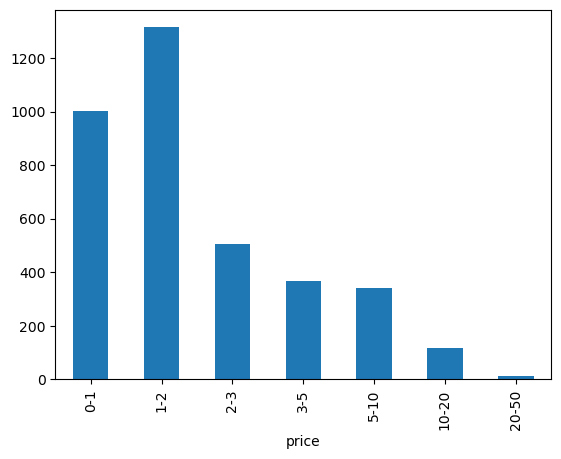

In [30]:
# price binning
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

- The majority of properties are priced in the "1-2 crores" and "2-3 crores" ranges.
- There's a significant drop in the number of properties priced above "5 crores."

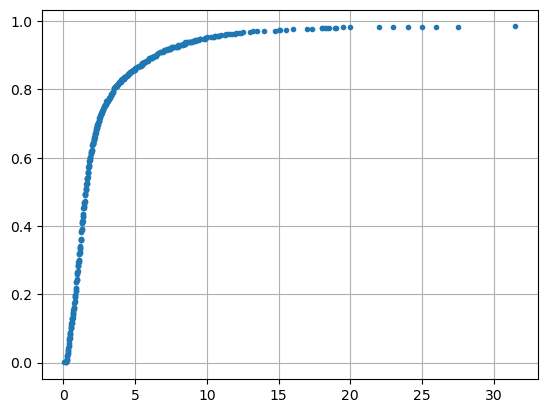

In [31]:
# ecdf plot
ecdf = df['price'].value_counts().sort_index().cumsum() / len(df['price'])
plt.plot(ecdf.index, ecdf, marker='.', linestyle='none')
plt.grid()

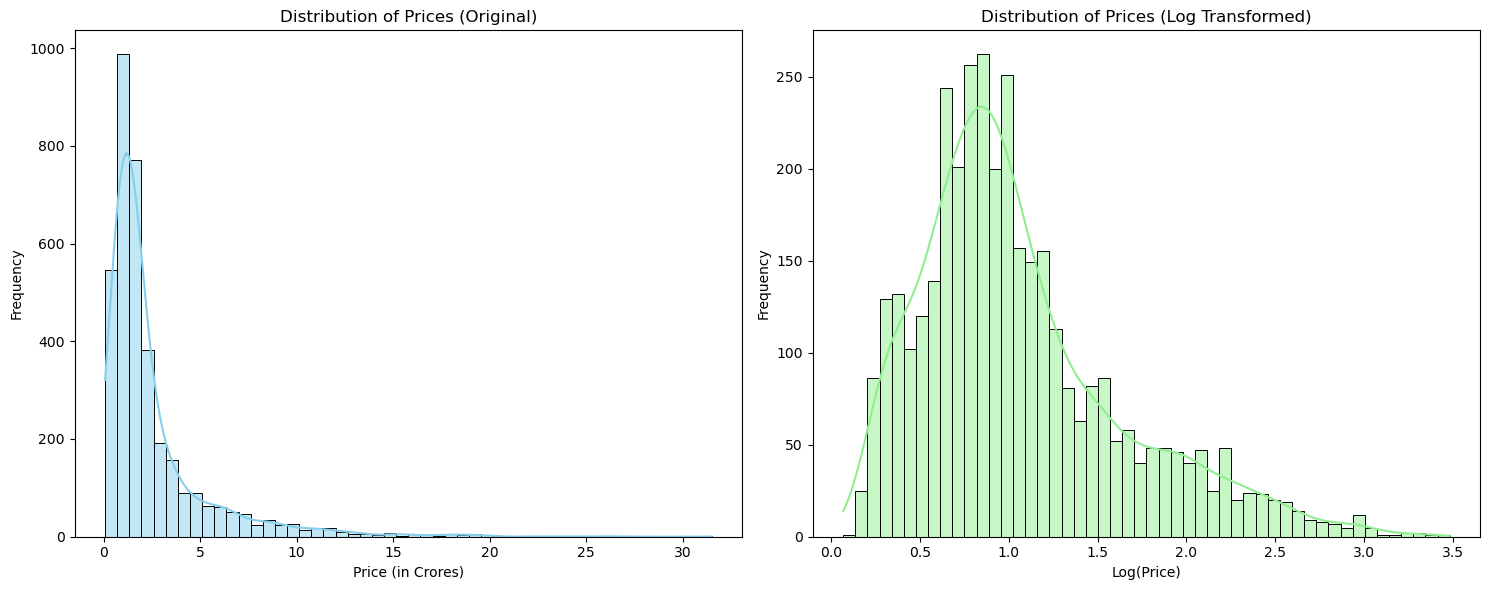

In [32]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [33]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.0740709565255313 0.9646692415449274


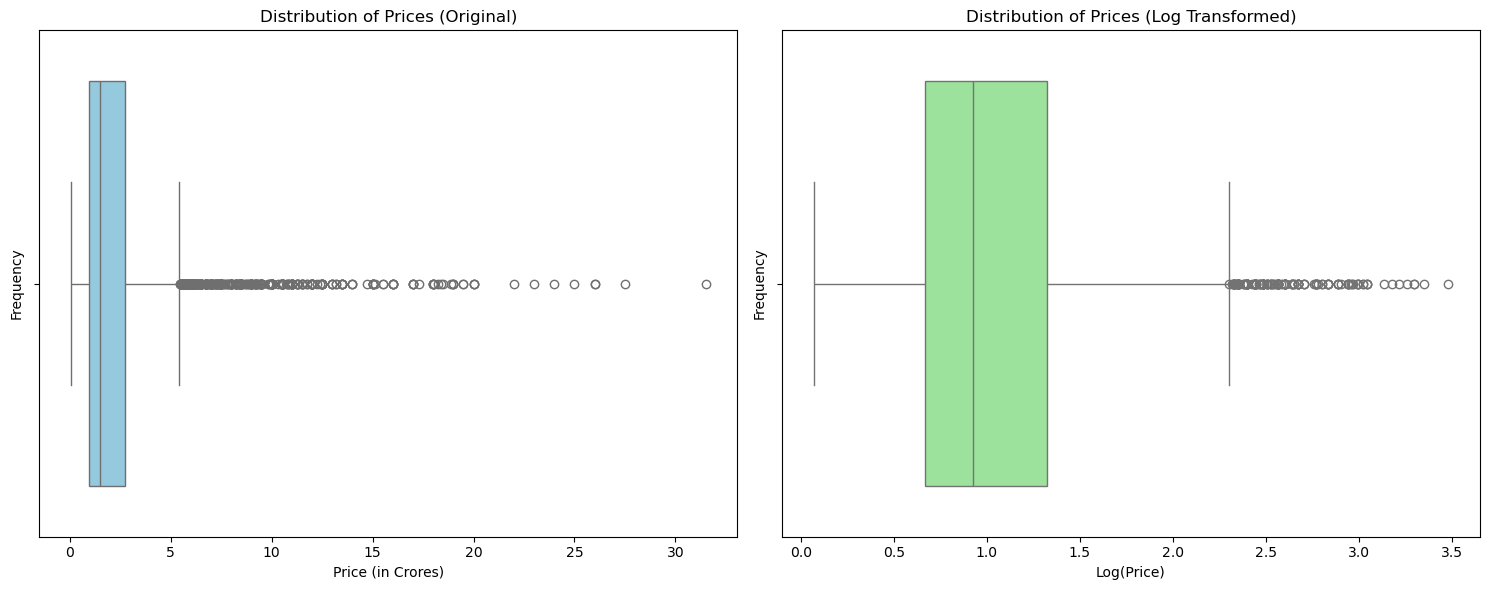

In [34]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(x=df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(x=np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [35]:
# price_per_sqft
df['price_per_sqft'].isnull().sum()

np.int64(25)

In [36]:
df['price_per_sqft'].describe()

count      3693.000000
mean      13920.877606
std       23128.300174
min           4.000000
25%        6839.000000
50%        9039.000000
75%       13913.000000
max      600000.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

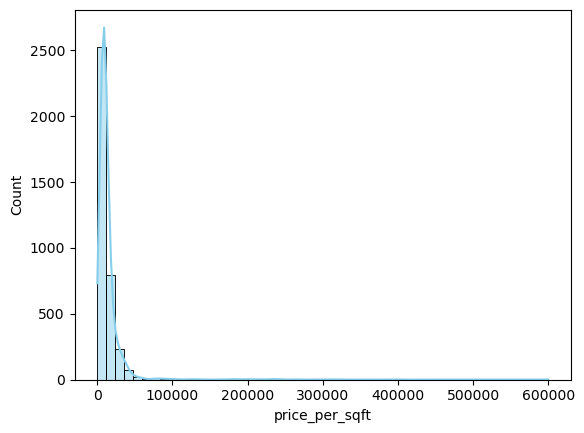

In [37]:
sns.histplot(df['price_per_sqft'], bins=50, color='skyblue', kde=True)

- Most properties have a price_per_sqft ranging between approximately ₹0 and ₹40,000. There is a significant concentration in the lower range, with a few properties having exceptionally high price_per_sqft.

<Axes: xlabel='price_per_sqft'>

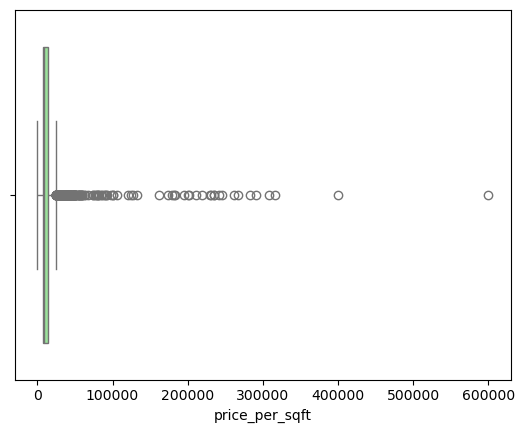

In [38]:
sns.boxplot(x=df['price_per_sqft'], color='lightgreen')

The box plot clearly shows several outliers, especially on the higher side. The interquartile range (IQR) is relatively compact, but there are many data points beyond the "whiskers" of the box plot, indicating potential outliers

- Observations
    - Potential Outliers
    - Right Skewed
    - 17 missing values

In [39]:
# bedRoom
df['bedRoom'].isnull().sum()

np.int64(41)

<Axes: xlabel='bedRoom'>

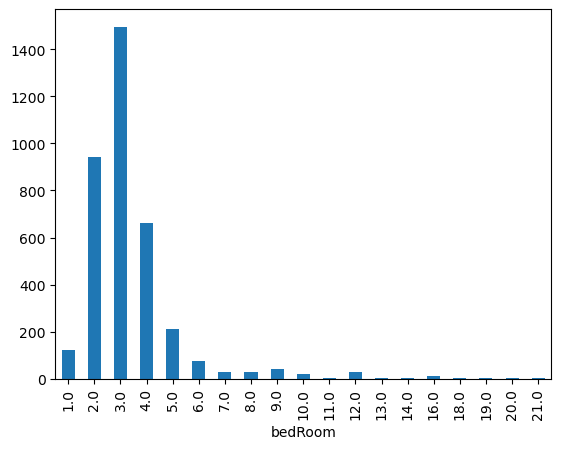

In [40]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

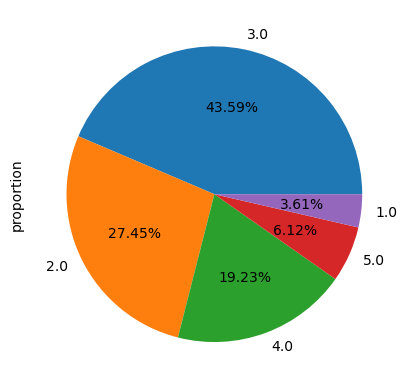

In [41]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [42]:
# bathroom
df['bathroom'].isnull().sum()

np.int64(41)

In [43]:
df['bathroom'].isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
3847    False
3848    False
3849     True
3850    False
3851    False
Name: bathroom, Length: 3718, dtype: bool

<Axes: xlabel='bathroom'>

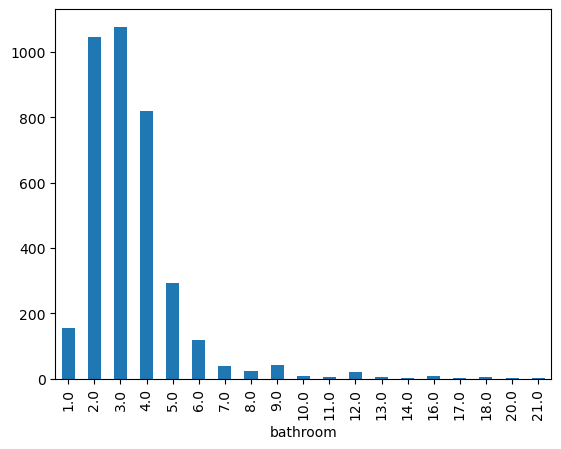

In [44]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

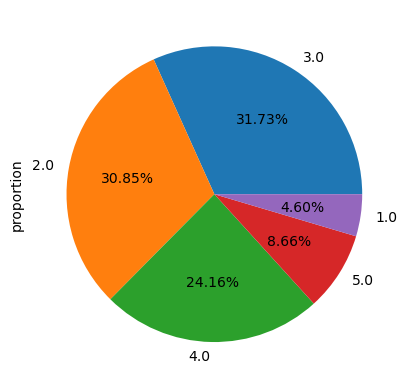

In [45]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [46]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,zara aavaas,sector 104,0.20,6644.0,301.0,Carpet area: 301 (27.96 sq.m.),1.0,2.0,2,...,NaN,NaN,301.0,0,0,0,0,0,0,67
1,flat,landmark the residency,sector 103,0.90,6666.0,1350.0,Super Built up area 1350(125.42 sq.m.),2.0,2.0,2,...,1350.0,NaN,NaN,0,0,0,0,0,0,44
2,flat,ramprastha city,dwarka expressway,1.30,9027.0,1440.0,Super Built up area 1440(133.78 sq.m.),3.0,3.0,2,...,1440.0,NaN,NaN,0,0,0,0,0,0,0
3,flat,ireo skyon,sector 60,3.80,13571.0,2800.0,Super Built up area 2800(260.13 sq.m.)Built Up...,4.0,5.0,3,...,2800.0,2791.0,2768.0,0,1,0,0,0,2,145
4,flat,breez global heights,sector 36,0.24,5825.0,412.0,Carpet area: 412 (38.28 sq.m.),1.0,1.0,1,...,NaN,NaN,412.0,0,0,0,0,0,0,57


In [47]:
# balcony
df['balcony'].isnull().sum()

np.int64(41)

<Axes: xlabel='balcony'>

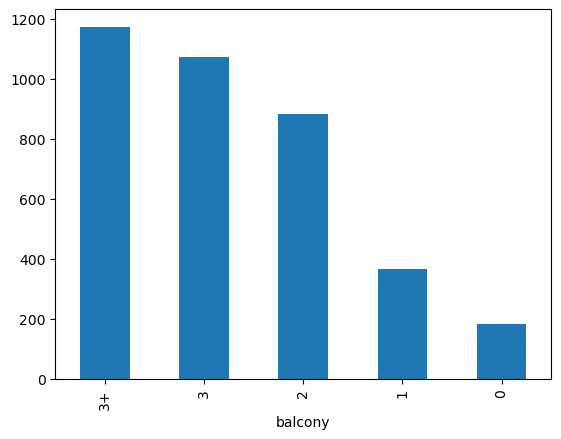

In [48]:
df['balcony'].value_counts().plot(kind='bar')

<Axes: ylabel='proportion'>

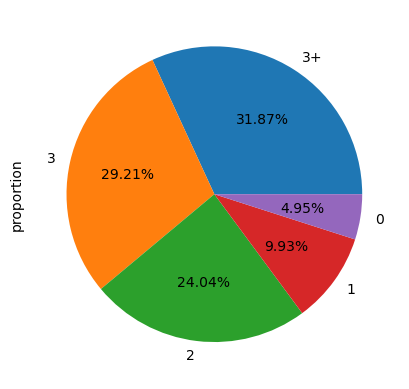

In [49]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [50]:
# floorNum
df.iloc[:,10:].head()

,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,3.0,NaN,New Property,NaN,NaN,301.0,0,0,0,0,0,0,67
1,1.0,South-West,Relatively New,1350.0,NaN,NaN,0,0,0,0,0,0,44
2,3.0,NaN,Under Construction,1440.0,NaN,NaN,0,0,0,0,0,0,0
3,15.0,East,Moderately Old,2800.0,2791.0,2768.0,0,1,0,0,0,2,145
4,8.0,NaN,New Property,NaN,NaN,412.0,0,0,0,0,0,0,57


In [51]:
df['floorNum'].isnull().sum()

np.int64(60)

In [52]:
df['floorNum'].describe()

count    3658.000000
mean        6.798250
std         6.012454
min         0.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

<Axes: xlabel='floorNum'>

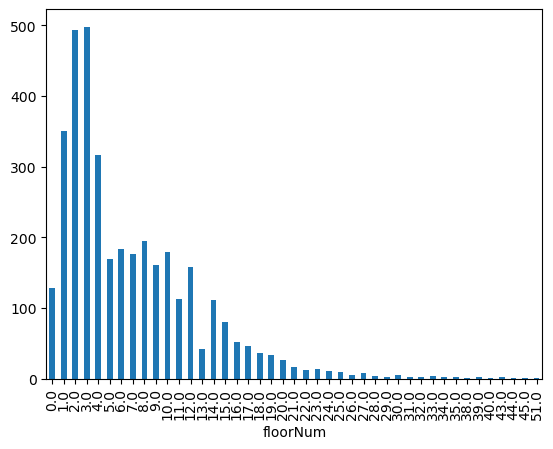

In [53]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: xlabel='floorNum'>

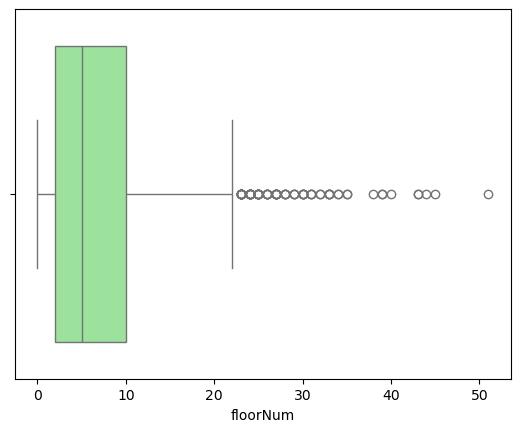

In [54]:
sns.boxplot(x=df['floorNum'], color='lightgreen')

- The majority of the properties lie between the ground floor (0) and the 25th floor.
- Floors 1 to 4 are particularly common, with the 3rd floor being the most frequent.
- There are a few properties located at higher floors, but their frequency is much lower.
- The box plot reveals that the majority of the properties are concentrated around the lower floors. The interquartile range (IQR) lies between - approximately the 2nd and 10th floors.
- Data points beyond the "whiskers" of the box plot, especially on the higher side, indicate potential outliers.

In [55]:
# facing
df['facing'].isnull().sum()

np.int64(1086)

In [56]:
df['facing'].fillna('NA',inplace=True)

C:\Users\anish\AppData\Local\Temp\ipykernel_20404\3692945726.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['facing'].fillna('NA',inplace=True)


In [57]:
df['facing'].value_counts()

facing
NA            1086
East           623
North-East     623
North          387
West           249
South          231
North-West     193
South-East     173
South-West     153
Name: count, dtype: int64

In [58]:
# agePossession
df['agePossession'].isnull().sum()

np.int64(0)

In [59]:
df['agePossession'].value_counts()

agePossession
Relatively New        1646
New Property           593
Moderately Old         563
Undefined              347
Old Property           303
Under Construction     266
Name: count, dtype: int64

In [60]:
# areas
# super built up area
df['super_built_up_area'].isnull().sum()

np.int64(1843)

In [61]:
df['super_built_up_area'].describe()

count     1875.000000
mean      1925.237627
std        764.172177
min         89.000000
25%       1479.500000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

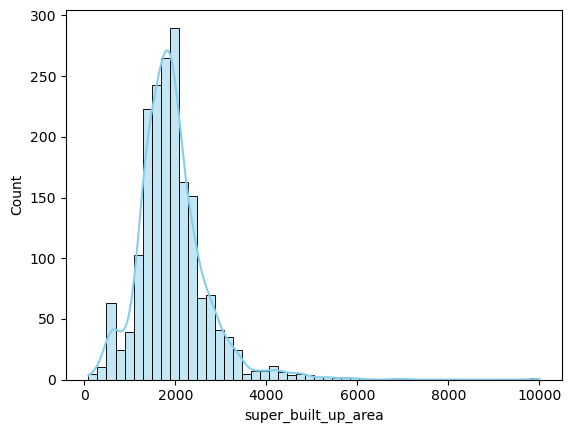

In [62]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: xlabel='super_built_up_area'>

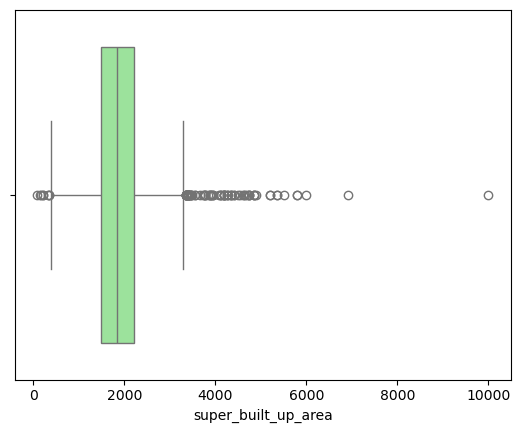

In [63]:
sns.boxplot(x=df['super_built_up_area'].dropna(), color='lightgreen')

- Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.
- There are a few properties with a significantly larger area, leading to a right-skewed distribution.
- The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.
- There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

In [64]:
# built up area
df['built_up_area'].isnull().sum()

np.int64(2028)

In [65]:
df['built_up_area'].describe()

count      1690.000000
mean       1841.931378
std       17945.374399
min           2.000000
25%         360.000000
50%        1256.500000
75%        1900.000000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

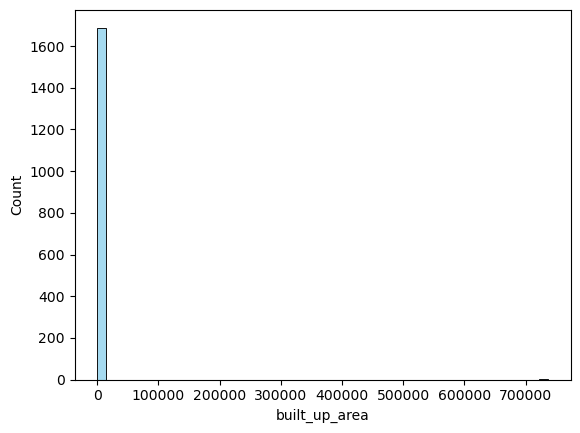

In [66]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: xlabel='built_up_area'>

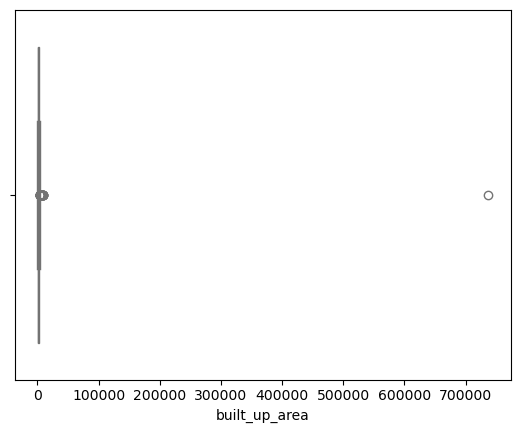

In [67]:
sns.boxplot(x=df['built_up_area'].dropna(), color='lightgreen')

- Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.
- There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.
- The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers.

The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors. This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed.

In [68]:
# carpet area
df['carpet_area'].isnull().sum()

np.int64(1846)

In [69]:
df['carpet_area'].describe()

count      1872.000000
mean       2529.179507
std       22799.836449
min          15.000000
25%         843.000000
50%        1300.000000
75%        1790.000000
max      607936.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

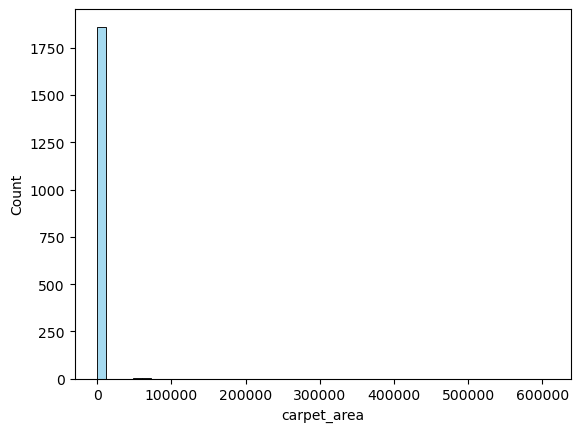

In [70]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: xlabel='carpet_area'>

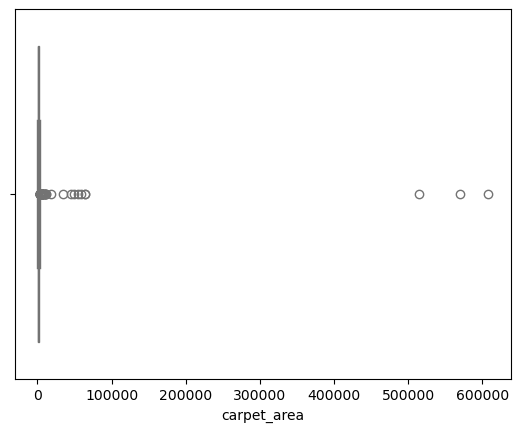

In [71]:

sns.boxplot(x=df['carpet_area'].dropna(), color='lightgreen')

In [72]:
df.iloc[:,16:]

,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,0,0,0,0,0,67
1,0,0,0,0,0,0,44
2,0,0,0,0,0,0,0
3,0,1,0,0,0,2,145
4,0,0,0,0,0,0,57
...,...,...,...,...,...,...,...
3847,1,0,0,0,0,1,107
3848,0,0,0,0,0,0,42
3849,0,0,0,0,0,0,46
3850,0,0,0,0,0,0,7


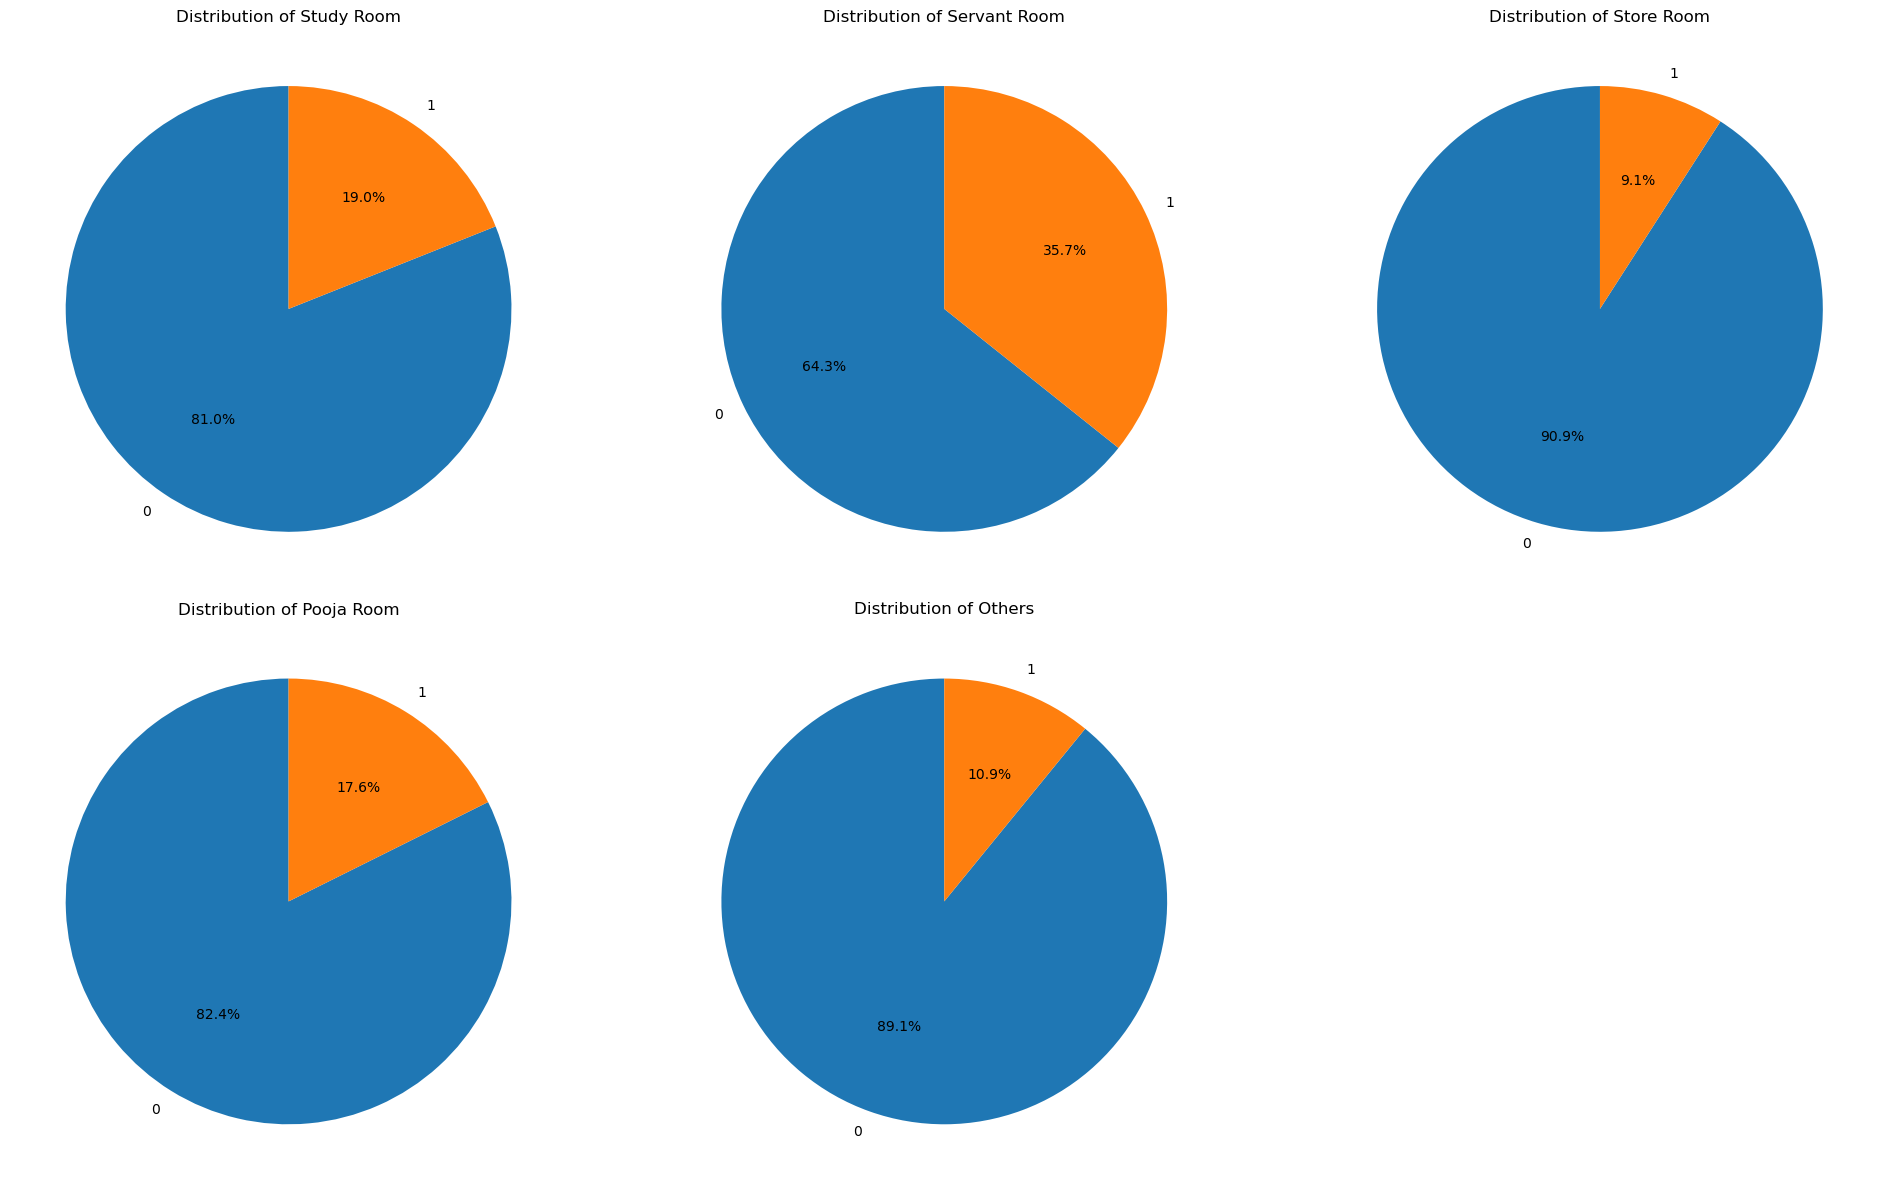

In [73]:
# additional rooms
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [74]:
# furnishing_type
df['furnishing_type'].value_counts()

furnishing_type
0    2476
2    1039
1     203
Name: count, dtype: int64

<Axes: ylabel='count'>

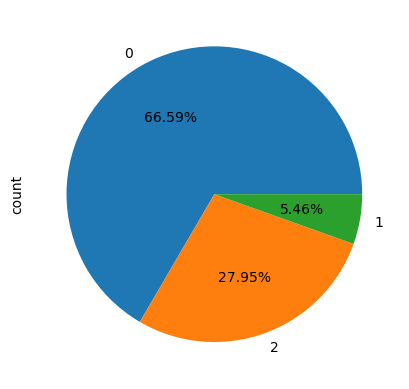

In [75]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [76]:
# luxury score
df['luxury_score'].isnull().sum()

np.int64(0)

In [77]:
df['luxury_score'].describe()

count    3718.000000
mean       71.119150
std        52.974048
min         0.000000
25%        31.000000
50%        58.000000
75%       109.750000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

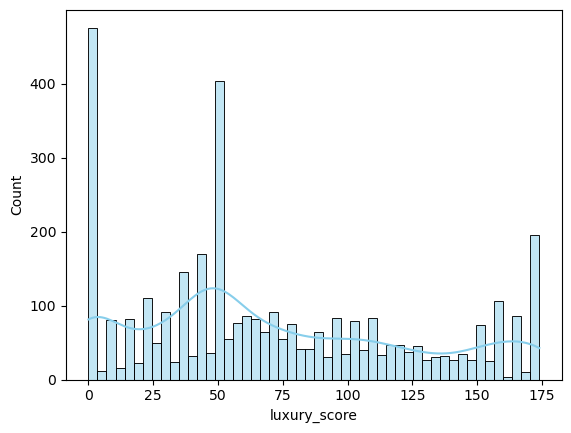

In [78]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: xlabel='luxury_score'>

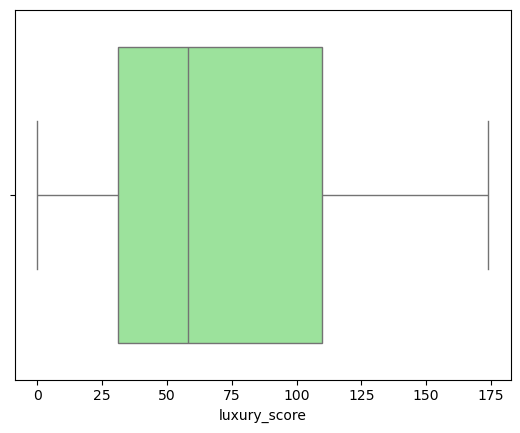

In [80]:
sns.boxplot(x=df['luxury_score'], color='lightgreen')

The luxury score distribution has multiple peaks, suggesting a multi-modal distribution. There's a significant number of properties with lower luxury scores (around 0-50), and another peak is observed around the 110-130 range.

The box plot reveals that the majority of the properties have luxury scores between approximately 30 and 110. The interquartile range (IQR) lies between these values.

In [ ]:
df.head()